# Project 2 — Image Compression using Singular Value Decomposition

This project investigates the use of truncated Singular Value Decomposition (SVD)
for image compression. Three images with different structural characteristics are
compared: a smooth sky image, a highly detailed foliage image, and a building image
containing a mixture of smooth regions and sharp edges.

The analysis evaluates the trade-off between reconstruction quality and storage,
and compares three methods for selecting the truncation rank k.

In [52]:
pip install numpy pandas matplotlib pillow scikit-image


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
#Import the libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [74]:
#Set the random seed
seed = 42
rng = np.random.default_rng(seed)

In [55]:
#Setup the images path

IMAGE_FOLDER = Path("images")

image_paths = {
    "Smooth - Sky" : IMAGE_FOLDER / "smooth.jpg",
    "Detailed - Foliage" : IMAGE_FOLDER / "detailed.jpg",
    "Mixed - Buildings" : IMAGE_FOLDER / "mixed.jpg"
}

In [56]:
#Create the greyscale conversion function
def load_grayscale(path, max_size=750):
    image = Image.open(path).convert("RGB")

    # Resize only if the image is larger than max_size
    image.thumbnail((max_size, max_size))

    image = np.array(image, dtype=float)

    image = image / 255.0

    gray = (
        0.2126 * image[:, :, 0]
        + 0.7152 * image[:, :, 1]
        + 0.0722 * image[:, :, 2]
    )

    return gray

In [57]:
#Load all three images
images = {}

for name, path in image_paths.items():
    images[name] = load_grayscale(path)

In [58]:
#Check that the images loaded correctly

for name,image in images.items():
    print(name)
    print("Shape: ", image.shape)
    print("Data Type: ", image.dtype)

Smooth - Sky
Shape:  (493, 740)
Data Type:  float64
Detailed - Foliage
Shape:  (450, 675)
Data Type:  float64
Mixed - Buildings
Shape:  (750, 631)
Data Type:  float64


In [59]:
#Report the number of values in each image

image_information = []

for name, image in images.items():

    m, n = image.shape

    image_information.append(
        {
            "Image": name,
            "Height (m)": m,
            "Width (n)" : n,
            "Numbers in original image" : m * n
        }
    )

image_info_df = pd.DataFrame(image_information)

image_info_df

,Image,Height (m),Width (n),Numbers in original image
0,Smooth - Sky,493,740,364820
1,Detailed - Foliage,450,675,303750
2,Mixed - Buildings,750,631,473250


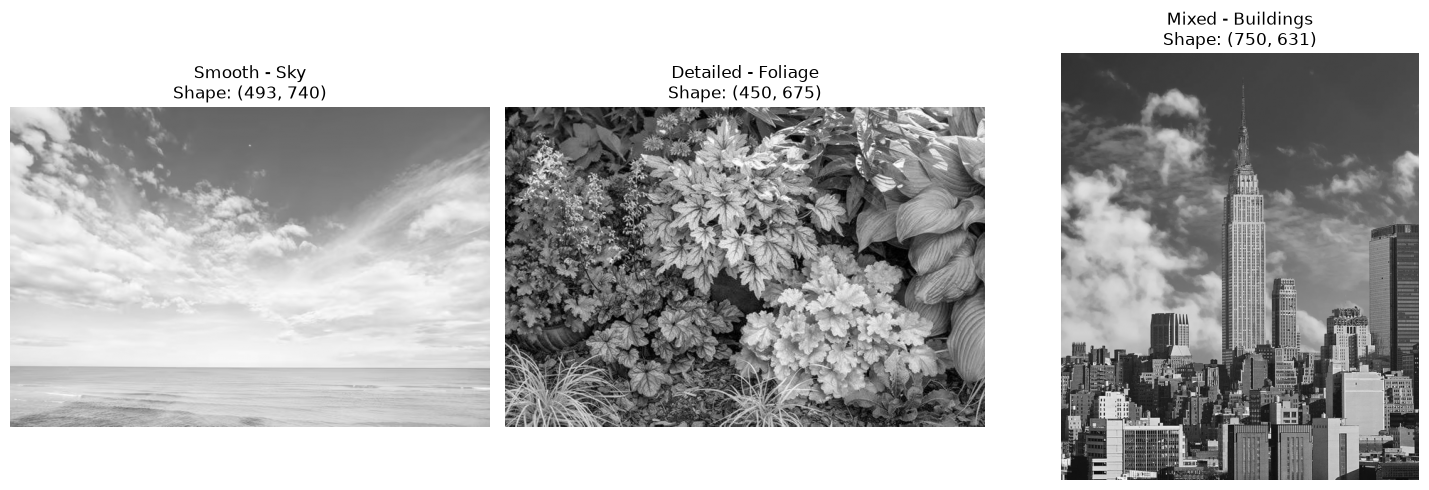

In [60]:
#Display the original image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, image) in zip(axes, images.items()):

    ax.imshow(image, cmap="gray", vmin=0, vmax=1)

    ax.set_title(
        f"{name}\nShape: {image.shape}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

The three images were selected to represent different levels of spatial complexity.

The sky image contains large areas where neighbouring pixels have similar intensity,
so I expect it to have substantial redundancy.

The foliage image contains many small edges, leaves and local intensity changes,
so I expect its information to be distributed across more SVD components.

The building image contains both relatively smooth surfaces and strong geometric
edges, so I expect its behaviour to fall between the other two images.

In [61]:
#Compute the SVD

svd_results = {}

for name, image in images.items():

    U, s, Vt = np.linalg.svd(
        image,
        full_matrices=False
    )

    svd_results[name] = {
        "U": U,
        "s": s,
        "Vt": Vt
    }

    print(name)
    print("U Shape: ", U.shape)
    print("Number of singular values: ", len(s))
    print("Vt Shape: ", Vt.shape)
    print()

Smooth - Sky
U Shape:  (493, 493)
Number of singular values:  493
Vt Shape:  (493, 740)

Detailed - Foliage
U Shape:  (450, 450)
Number of singular values:  450
Vt Shape:  (450, 675)

Mixed - Buildings
U Shape:  (750, 631)
Number of singular values:  631
Vt Shape:  (631, 631)



In [62]:
#Write the reconstruction function

def reconstruct_image(U, s, Vt, k):

    U_k = U[:, :k]

    s_k = s[:k]

    Vt_k = Vt[:k, :]

    reconstructed = U_k @ np.diag(s_k) @ Vt_k

    return reconstructed

In [63]:
#Full-rank verification

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    reconstructed = reconstruct_image(
        U, s, Vt, full_rank
    )

    check = np.allclose(
        image,
        reconstructed
    )

    max_difference = np.max(
        np.abs(image - reconstructed)
    )

    print(name)
    print("Full-rank reconstruction correct:", check)
    print("Maximum difference:", max_difference)
    print()

Smooth - Sky
Full-rank reconstruction correct: True
Maximum difference: 3.0941915696303113e-13

Detailed - Foliage
Full-rank reconstruction correct: True
Maximum difference: 1.1507461650239748e-13

Mixed - Buildings
Full-rank reconstruction correct: True
Maximum difference: 5.53113110868253e-13



In [64]:
#Create the measurement function

def calculate_metrics(image, U, s, Vt, k):

    m, n = image.shape

    reconstructed = reconstruct_image(
        U, s, Vt, k
    )

    numbers_stored = k * (m + n + 1)

    compression_ratio = (
        (m * n) / numbers_stored
    )

    relative_error = (
        np.linalg.norm(image - reconstructed, ord="fro")
        / np.linalg.norm(image, ord="fro")
    )

    energy_retained = (
        np.sum(s[:k] ** 2)
        / np.sum(s ** 2)
    )

    return (
        numbers_stored,
        compression_ratio,
        relative_error,
        energy_retained
    )

In [65]:
#Calculate break-even k

def calculate_break_even(image):

    m, n = image.shape

    break_even = (
        (m * n) / (m + n + 1)
    )

    return break_even

In [66]:
for name, image in images.items():

    break_even = calculate_break_even(image)

    first_expanding_k = (
        int(np.floor(break_even)) + 1
    )

    print(name)
    print(
        "Break-even k:",
        round(break_even, 2)
    )
    print(
        "First integer k storing more than original:",
        first_expanding_k
    )
    print()

Smooth - Sky
Break-even k: 295.64
First integer k storing more than original: 296

Detailed - Foliage
Break-even k: 269.76
First integer k storing more than original: 270

Mixed - Buildings
Break-even k: 342.44
First integer k storing more than original: 343



In [67]:
#Choose reconstruction k values
base_k_values = [
    1,
    5,
    10,
    20,
    50,
    100
]

In [68]:
#Build the complete results table

results = []

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    k_values = []

    for k in base_k_values:

        if k <= full_rank:
            k_values.append(k)

    k_values.append(full_rank)

    k_values = sorted(set(k_values))

    for k in k_values:

        stored, ratio, error, energy = calculate_metrics(
            image,
            U,
            s,
            Vt,
            k
        )

        results.append({
            "Image": name,
            "k": k,
            "Numbers Stored": stored,
            "Compression Ratio": ratio,
            "Relative Error": error,
            "Energy Retained": energy
        })

results_df = pd.DataFrame(results)

results_df

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Smooth - Sky,1,1234,295.640194,1.066646e-01,0.988623
1,Smooth - Sky,5,6170,59.128039,5.168444e-02,0.997329
2,Smooth - Sky,10,12340,29.564019,3.970220e-02,0.998424
3,Smooth - Sky,20,24680,14.782010,2.685022e-02,0.999279
4,Smooth - Sky,50,61700,5.912804,1.389552e-02,0.999807
5,Smooth - Sky,100,123400,2.956402,6.896365e-03,0.999952
6,Smooth - Sky,493,608362,0.599676,1.374236e-14,1.000000
7,Detailed - Foliage,1,1126,269.760213,4.016231e-01,0.838699
8,Detailed - Foliage,5,5630,53.952043,3.169892e-01,0.899518
9,Detailed - Foliage,10,11260,26.976021,2.778089e-01,0.922822


In [69]:
#Display a cleaner results table

display_results = results_df.copy()

display_results["Compression Ratio"] = (
    display_results["Compression Ratio"]
    .map(lambda x: f"{x:.2f}x")
)

display_results["Relative Error"] = (
    display_results["Relative Error"]
    .map(lambda x: f"{x:.4f}")
)

display_results["Energy Retained"] = (
    display_results["Energy Retained"]
    .map(lambda x: f"{100*x:.2f}%")
)

display_results

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Smooth - Sky,1,1234,295.64x,0.1067,98.86%
1,Smooth - Sky,5,6170,59.13x,0.0517,99.73%
2,Smooth - Sky,10,12340,29.56x,0.0397,99.84%
3,Smooth - Sky,20,24680,14.78x,0.0269,99.93%
4,Smooth - Sky,50,61700,5.91x,0.0139,99.98%
5,Smooth - Sky,100,123400,2.96x,0.0069,100.00%
6,Smooth - Sky,493,608362,0.60x,0.0000,100.00%
7,Detailed - Foliage,1,1126,269.76x,0.4016,83.87%
8,Detailed - Foliage,5,5630,53.95x,0.3170,89.95%
9,Detailed - Foliage,10,11260,26.98x,0.2778,92.28%


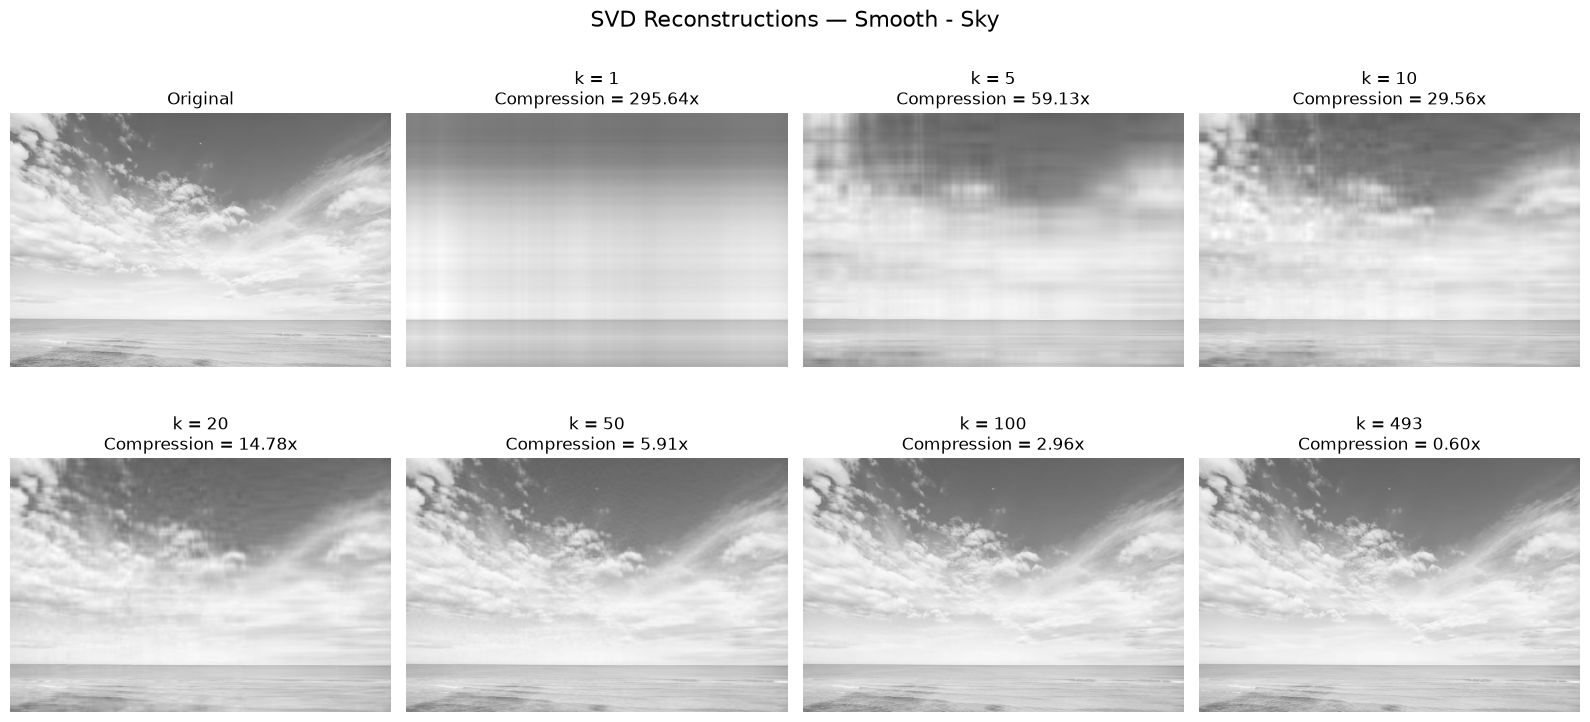

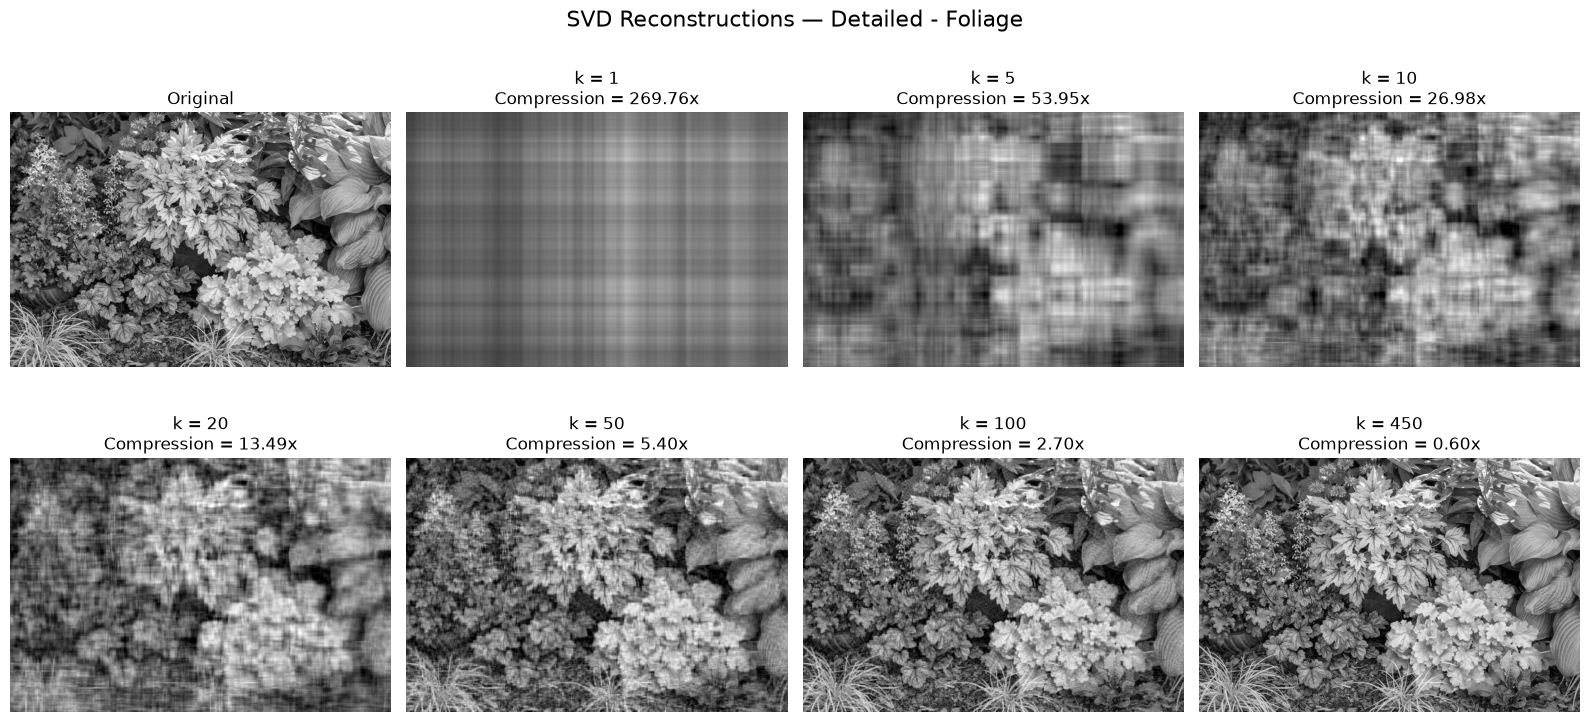

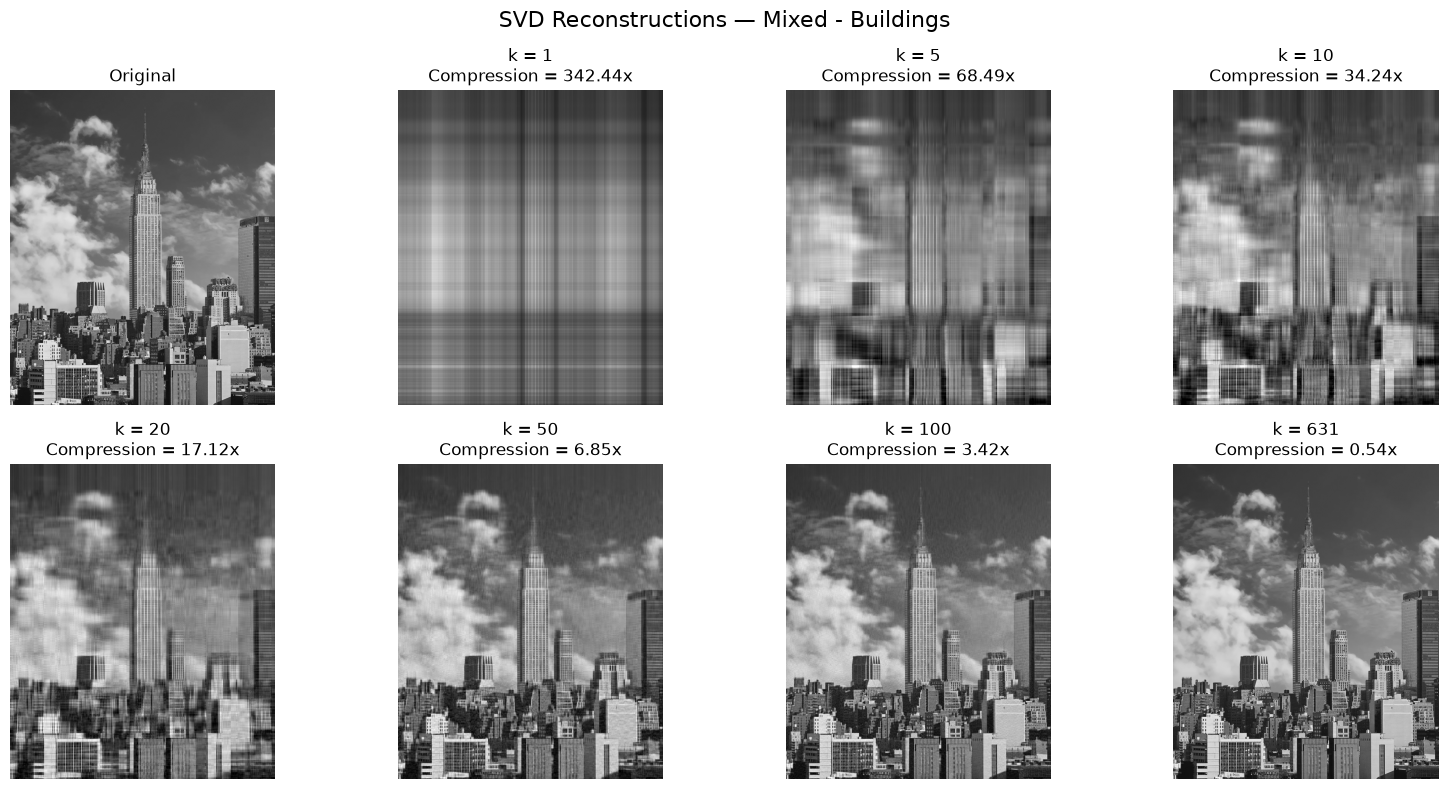

In [77]:
#Reconstruction grids

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    k_values = [
        k for k in base_k_values
        if k <= full_rank
    ]

    k_values.append(full_rank)
    k_values = sorted(set(k_values))

    total_plots = len(k_values) + 1

    columns = 4
    rows = int(np.ceil(total_plots / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    axes[0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title("Original")
    axes[0].axis("off")

    for index, k in enumerate(
        k_values,
        start=1
    ):

        reconstructed = reconstruct_image(
            U,
            s,
            Vt,
            k
        )

        reconstructed_display = np.clip(
            reconstructed,
            0,
            1
        )

        stored, ratio, error, energy = calculate_metrics(
            image,
            U,
            s,
            Vt,
            k
        )

        axes[index].imshow(
            reconstructed_display,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[index].set_title(
            f"k = {k}\n"
            f"Compression = {ratio:.2f}x"
        )

        axes[index].axis("off")

    for index in range(
        total_plots,
        len(axes)
    ):
        axes[index].axis("off")

    plt.suptitle(
        f"SVD Reconstructions — {name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()